## Graph Neural Networks

In our previous work, we experimented with classical statistical models (Logistic Regression, Random Forest, Gradient Boosted Trees, etc.) to classify transaction labels. Most models achieved satisfactory performance, with the best model (ExtraTrees) reaching a PR-AUC of  0.5715 and a ROC-AUC of 0.8687 on the testing set. However, it is important to note that these models do not leverage the graph structure of the data. They rely solely on node features and ignore the edge list, thereby discarding potentially valuable topological information encoded in the transaction network.


In this notebook, we explore **Graph Neural Networks (GNNs)** with two primary goals:

1. Develop strong GNN models that perform well on the node classification task.

2. Extract node embeddings from the GNN’s hidden layers for use in downstream hybrid models.

For the second objective, recall that GNNs naturally learn node embeddings, representing each node as a vector in $\mathbb{R}^N$. These embeddings are designed so that nodes with similar structural roles or connectivity patterns are mapped to nearby points in the embedding space. If successful, these learned embeddings can serve as additional features alongside the original node attributes. By augmenting statistical models with these embeddings, we aim to improve their predictive performance.
```

In [2]:
import torch
from torch_geometric.data import Data

elliptic = torch.load("../Dataset/processed/transaction_graph_v1.pt", weights_only=False, map_location="cpu")
txs_data = Data(**elliptic[0])
txs_data

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

In [ ]:
# Implement strict time-forward train/val/test split
time_steps = txs_data.x[:,0]
train_mask = (time_steps >= 1) & (time_steps <= 32)
val_mask = (time_steps >= 33) & (time_steps <= 37)
test_mask = (time_steps >= 38) & (time_steps <= 42)

# Select the labeled data and make the train/val/test sets
labeled = txs_data.y != 2
train_idx = train_mask & labeled
val_idx = val_mask & labeled
test_idx = test_mask & labeled

print("The size of the training set is:", train_idx.sum().item())
print("The size of the validation set is:",val_idx.sum().item())
print("The size of the testing set is:", test_idx.sum().item())

The size of the training set is: 28938
The size of the validation set is: 4503
The size of the testing set is: 6436


### Graph Convolutional Network (GCN)

Say a graph has $V$ nodes, and we want to embed each node as a vector in $\mathbb{R}^N$. Then the **embedding matrix** has size $V \times N$. One way to turn graph nodes into embeddings is through a Graph Convolutional Network (GCN). The GCN has the following architecture.

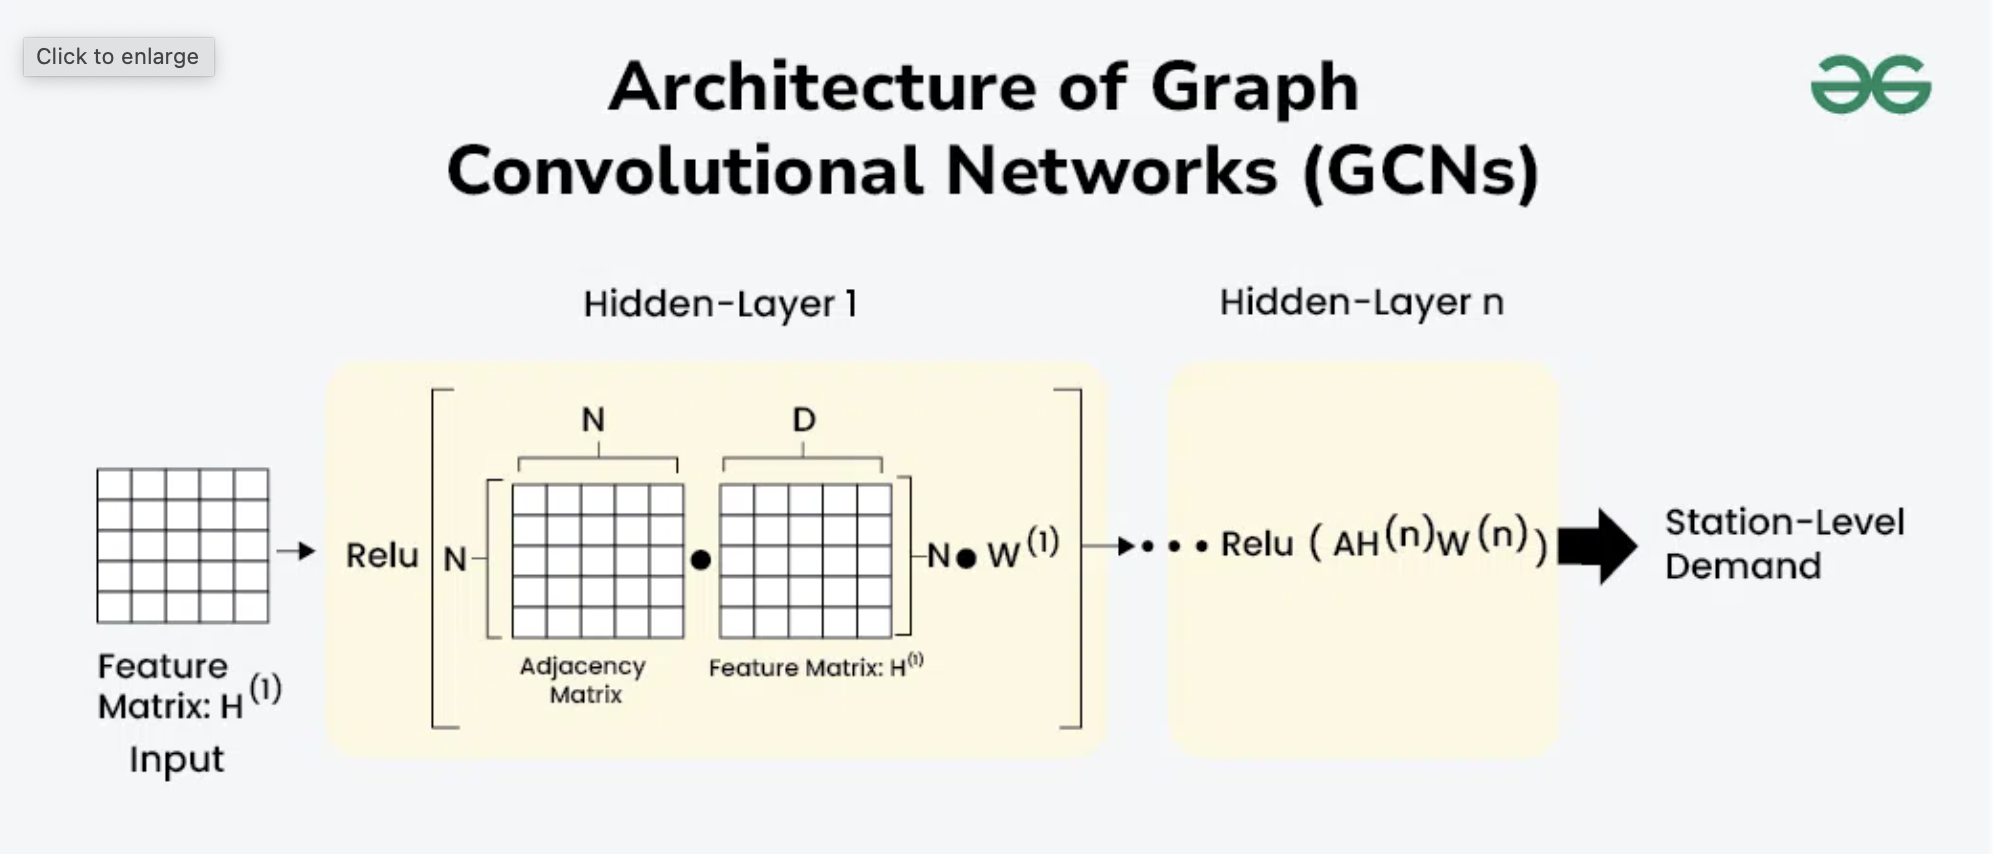


In particular, the $l$-th layer of takes the adjacency matrix $A$ and the node embedding matrix $H^{l}$ (from the previous layer) as input, and uses a weight matrix $W^{l}$ to update the node embedding matrix to $H^{l+1}$ as output. Mathematically, we have

\begin{equation*}
H^{(l+1)} = \sigma (\hat{A} H^{(l)} W)
\end{equation*}

where $\hat{A} = \tilde{D}^{-\frac{1}{2}}\tilde{A}\tilde{D}^{-\frac{1}{2}}$, $\tilde{A} = A + I$, $\tilde{D} = \text{diag}(\sum_{j}\tilde{A}_{ij})$, where $\sigma$ is the activation function (usually ReLu) for all but the output layer. The initial embedding matrix comes from node features, i.e. $H^{(0)} = X$. In the case of node classification, the output layer is the softmax; if there are $L$ total layers, then where $H^{(L)}$ consists of prediction probabilities.

In the following code, we implement a GCN of two layers, whose final output can be explicitly written as
\begin{equation*}
H^{(2)} = \text{softmax}(\hat{A} \cdot \text{ReLU}(H^{(1)})\cdot W^{(1)})
\end{equation*}
where
\begin{equation*}
H^{(1)} = \hat{A} X W^{(0)}
\end{equation*}
is the embedding matrix.

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
  # Define the model architecture
  def __init__(self, in_channels, hidden_channels, out_channels, dropout = 0.0):
    super().__init__()
    self.conv1 = GCNConv(in_channels, hidden_channels)
    self.conv2 = GCNConv(hidden_channels, out_channels)
    self.dropout = dropout

    # Define the forward pass
  def forward(self, x, edge_index, return_embeddings=False):
    h1 = F.relu(self.conv1(x, edge_index)) # compute the embedding matrix
    h1 = F.dropout(h1, p = self.dropout, training = self.training)
    logits = self.conv2(h1, edge_index)
    if return_embeddings:
      return logits, h1
    return logits

## GraphSage

Our second model, **GraphSAGE (Graph Sample and Aggregate)**, is an inductive Graph Neural Network that learns node representations by sampling and aggregating features from a node’s local neighborhood. Unlike GCN, which relies on full-graph message passing, GraphSAGE samples a fixed number of neighbors and applies learnable aggregation functions (e.g., mean or max). This makes it more scalable to large graphs and allows it to generalize to unseen nodes. In practice, GraphSAGE can outperform GCN due to its flexibility in aggregation and its ability to mitigate over-smoothing by focusing on localized, sampled neighborhoods.

In [ ]:
from torch_geometric.nn import SAGEConv

class SAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits = self.conv2(h, edge_index)
        if return_embeddings:
            return logits, h
        return logits

## GraphGPS

Our final candidate, **GraphGPS (General, Powerful, Scalable Graph Transformer)**, is a GNN architecture that combines local message passing (e.g., GCN/GraphSAGE) with global attention mechanisms (via Transformers). The local component captures neighborhood structure, while the attention layer allows each node to attend to all other nodes, incorporating long-range dependencies.

Attention can potentially improve performance because it enables the model to adaptively weight important nodes, rather than treating all neighbors equally as in standard GNNs. This is especially useful in graphs where relevant information comes from distant or non-local structures. By combining local aggregation with global attention, GPS can learn richer and more expressive representations, often leading to better performance on complex graph tasks.

In [ ]:
from torch_geometric.nn import GPSConv

class GraphGPS(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout = 0.3, attn_type='performer',):
        super().__init__()

        self.input_proj = torch.nn.Linear(in_channels, hidden_channels)

        # Local MPNN
        local_mpnn1 = SAGEConv(hidden_channels, hidden_channels)
        local_mpnn2 = SAGEConv(hidden_channels, hidden_channels)

        # Global attention
        self.gps1 = GPSConv(channels=hidden_channels, conv=local_mpnn1, heads=heads, dropout=dropout, attn_type=attn_type, attn_kwargs={'dropout': dropout},)
        self.gps2 = GPSConv(channels=hidden_channels, conv=local_mpnn2, heads=heads, dropout=dropout, attn_type=attn_type, attn_kwargs={'dropout': dropout},)

        self.classifier = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, batch=None, return_embeddings=False):
        if batch is None:
            batch = x.new_zeros(x.size(0), dtype=torch.long)

        x = self.input_proj(x)
        x = self.gps1(x, edge_index, batch=batch)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gps2(x, edge_index, batch=batch)
        h = x
        logits = self.classifier(h)

        if return_embeddings:
            return logits, h
        return logits

## Code for training and evaluation

### Preparing the data

In [ ]:
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import StandardScaler

# Load the dataset
feature_idx = torch.tensor(list(range(1, 93))  + [105, 115, 120, 132, 138])
x = txs_data.x[:,feature_idx]
y = txs_data.y
edge_index = txs_data.edge_index
edge_index_undir = to_undirected(edge_index) #conversion to undirected graph

# Feature scaling
mean = x[train_idx].mean(0, keepdim=True)
std = x[train_idx].std(0, keepdim=True)
x = (x - mean) / (std + 1e-8)

# Store the dataset on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_gpu = x.to(device)
y_gpu = y.to(device)
edge_index_gpu = edge_index.to(device)
edge_index_undir_gpu = edge_index_undir.to(device)

train_idx_gpu = train_idx.to(device)
val_idx_gpu = val_idx.to(device)
test_idx_gpu = test_idx.to(device)

# Compute class weights from train labels
y_train = y_gpu[train_idx_gpu]
nums_0 = (y_train == 0).sum().item()
nums_1 = (y_train == 1).sum().item()

w0 = 1.0
w1 = nums_0/max(nums_1, 1)
class_weight = torch.tensor([w0, w1], device = device)

### Training

We train the model using the Adam optimizer with weight decay for regularization, and monitor performance on the validation set after each epoch. In each training epoch, the model first performs a forward pass on the graph, computes the cross-entropy loss on the training nodes, and then updates the parameters through backpropagation. After that, we switch to evaluation mode and compute the **average precision (AP)** on the validation set, which serves as our main metric for model selection.

To make training more stable, we use a `ReduceLROnPlateau` scheduler, which lowers the learning rate whenever the validation AP stops improving sufficiently. This helps the optimizer take smaller steps once progress slows down.

We also use **early stopping**, which is especially important because GNNs can easily overfit the training graph. Instead of always training for the full number of epochs, we stop when the validation AP has failed to improve by at least `min_delta` for patience consecutive epochs. This prevents the model from continuing to fit noise in the training set after it has already reached its best generalization performance. During training, we save the parameters that achieve the highest validation AP, and at the end we restore this best model rather than the last one.

In [ ]:
import copy
import random
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import average_precision_score
from IPython.display import clear_output

# Set random seed for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

def train(model, training_params: dict):
  # Extract the hyperparameters for training
  lr, weight_decay, patience, min_delta, factor, threshold, epochs = training_params.values()

  optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'max', patience = 0.5 * patience, factor = factor, threshold = threshold)

  best_val_ap, best_state = -1, None
  bad_epochs = 0
  for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    logits = model(x_gpu, edge_index_undir_gpu)
    loss = F.cross_entropy(logits[train_idx_gpu], y_gpu[train_idx_gpu], weight = class_weight)

    # Back pass
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
      logits = model(x_gpu, edge_index_undir_gpu)
      val_prob = F.softmax(logits[val_idx_gpu], dim = 1)[:,1]
      val_ap = average_precision_score(y[val_idx], val_prob.cpu().numpy())

      scheduler.step(val_ap)

    # Stop training if the performance on the validation set does not improve
    if val_ap > best_val_ap + min_delta:
      best_val_ap = val_ap
      best_state = copy.deepcopy(model.state_dict())
      bad_epochs = 0
    else:
      bad_epochs += 1

    if bad_epochs >= patience:
      break

    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, val_ap: {val_ap:.4f}")

  model.load_state_dict(best_state)
  print("Best average precision on the validation set is", best_val_ap)
  return model

### Evaluation

We want to accomplish three things here:

1. **Evaluation:** We evaluate the model using PR-AUC on train, validation, and test sets, and plot precision–recall curves. This metric is appropriate for imbalanced data.

2. **Time-Based Evaluation:** We further evaluate performance across test time steps, reporting PR-AUC, precision, recall, F1, and illicit rate to capture temporal variation.

3. **Embeddings:** We extract node embeddings from the model’s hidden layer for use in downstream hybrid models.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, precision_score, recall_score, f1_score

# Convert Torch tensors to NumPy arrays
y_np = y.numpy()
train_idx_np = train_idx.numpy()
val_idx_np = val_idx.numpy()
test_idx_np = test_idx.numpy()
time_np = time_steps.numpy()


# Evaluate the model on the entire dataset
def evaluate(model):
  with torch.no_grad():
    logits = model(x_gpu, edge_index_undir_gpu, return_embeddings=False)
    y_scores = F.softmax(logits, dim=1)[:,1]

    # Move tensors from GPU to CPU, and convert to NumPy arrays
    y_scores_np = y_scores.detach().cpu().numpy()

  # Compute precision and recall for training/validation/testing sets
  train_precision, train_recall, _ = precision_recall_curve(y_np[train_idx_np], y_scores_np[train_idx_np])
  val_precision, val_recall, _ = precision_recall_curve(y_np[val_idx_np], y_scores_np[val_idx_np])
  test_precision, test_recall, _ = precision_recall_curve(y_np[test_idx_np], y_scores_np[test_idx_np])
  print(f'The PR-AUC on the training set is: {auc(train_recall, train_precision):.4f}')
  print(f'The PR-AUC on the validation set is: {auc(val_recall, val_precision):.4f} ')
  print(f'The PR-AUC on the testing set is: {auc(test_recall, test_precision):.4f} ')

  plt.plot(train_recall, train_precision, label='Training set')
  plt.plot(val_recall, val_precision, label='Validation set')
  plt.plot(test_recall, test_precision, label='Testing set')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision-Recall Curve')
  plt.legend()
  plt.show()

  return y_scores_np

# Evaluate the performance for each time step in the testing set
def evaluate_by_timesteps(model, threshold = 0.5):
  with torch.no_grad():
    logits = model(x_gpu, edge_index_undir_gpu, return_embeddings=False)
    y_scores = F.softmax(logits, dim=1)[:,1]
    y_scores_np = y_scores.detach().cpu().numpy()

  rows = []
  for t in range(38, 43):
    mask_t = test_idx_np & (time_np == t)
    y_t = y_np[mask_t]
    y_scores_t = y_scores_np[mask_t]

    precision, recall, _ = precision_recall_curve(y_t, y_scores_t)
    pr_auc = auc(recall, precision)

    y_pred_t = (y_scores_t >= threshold).astype(int)
    p = precision_score(y_t, y_pred_t, zero_division = 0)
    r = recall_score(y_t, y_pred_t, zero_division = 0)
    f1 = f1_score(y_t, y_pred_t, zero_division = 0)


    rows.append({"time_step": t, "pr-auc": f"{pr_auc:.4f}",
    f"precision(p={threshold})": f"{p:.4f}",
    f"recall(p={threshold})": f"{r:.4f}",
    f"f1(p={threshold})": f"{f1:.4f}",
    f"illicit rate": f"{(y_t == 1).sum()/len(y_t):.4f}"})

  return pd.DataFrame(rows)

# Retrive the embedding matrix
def get_embeddings(model):
  model.eval()
  with torch.no_grad():
    _, h = model(x_gpu, edge_index_undir_gpu, return_embeddings=True)
    h = h.detach().cpu()
  return h

## Performance of GCN

In [ ]:
set_seed(7)
gcn =  GCN(in_channels = x.size(1), hidden_channels = 64, out_channels = 2, dropout=0.2).to(device)
training_params = {'Learning rate': 1e-3, 'Weight decay': 5e-3, # optimizer hyperparamters
          'Patience': 30, 'Min Delta': 1e-4, # early stopping hyperparameters
          'Factor': 0.8, 'Threshold': 1e-3, # scheduler hyperparameters
          'Epochs': 500} # total number of epochs
trained_gcn = train(gcn, training_params)

Epoch 500/500, Loss: 0.2488, val_ap: 0.5225
Best average precision on the validation set is 0.5225093504632157


The PR-AUC on the training set is: 0.8086
The PR-AUC on the validation set is: 0.5211 
The PR-AUC on the testing set is: 0.6022 


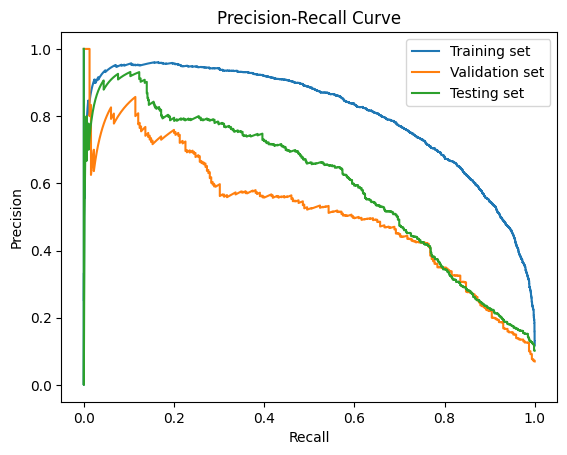

In [ ]:
y_scores = evaluate(trained_gcn)

In [ ]:
evaluate_by_timesteps(trained_gcn)

,time_step,pr-auc,precision(p=0.5),recall(p=0.5),f1(p=0.5),illicit rate
0,38,0.4465,0.2883,0.8468,0.4302,0.1468
1,39,0.3616,0.2345,0.8889,0.3711,0.0685
2,40,0.4809,0.1754,0.8393,0.2901,0.0925
3,41,0.6527,0.1923,0.9483,0.3198,0.1025
4,42,0.8001,0.2990,0.8996,0.4489,0.1110


In [ ]:
# Get the embedding matrix
h_gcn = get_embeddings(trained_gcn)
#torch.save(h_gcn, "../gnn/embeddings/gcn_embeddings.pt")
print("The embedding matrix has dimension", h_gcn.shape)
h_gcn

The embedding matrix has dimension torch.Size([203769, 64])


tensor([[0.1015, 0.1000, 0.0006,  ..., 0.1126, 0.2401, 0.0000],
        [0.2919, 0.2620, 0.1182,  ..., 0.3484, 0.0000, 0.2603],
        [0.2504, 0.1127, 0.0000,  ..., 0.0353, 0.1945, 0.2490],
        ...,
        [0.0000, 0.0388, 0.0404,  ..., 0.0000, 0.2717, 0.0000],
        [0.0000, 0.2831, 0.0000,  ..., 0.0000, 0.4508, 0.1068],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.2455, 0.0000]])

In [ ]:
#torch.save(trained_gcn.state_dict(), "../gnn/models/best_gcn.pt")

## Performance of GraphSage

In [ ]:
set_seed(11)
sage =  SAGE(in_channels = x.size(1), hidden_channels = 64, out_channels = 2).to(device)
training_params = {'Learning rate': 5e-4, 'Weight decay': 5e-3, # optimizer hyperparamters
          'Patience': 30, 'Min Delta': 1e-4, # early stopping hyperparameters
          'Factor': 0.8, 'Threshold': 1e-3, # schedul?er hyperparameters
          'Epochs': 300} # total number of epochs
trained_sage = train(sage, training_params)

Epoch 300/300, Loss: 0.1606, val_ap: 0.8235
Best average precision on the validation set is 0.8234956677869932


The PR-AUC on the training set is: 0.9331
The PR-AUC on the validation set is: 0.8232 
The PR-AUC on the testing set is: 0.8153 


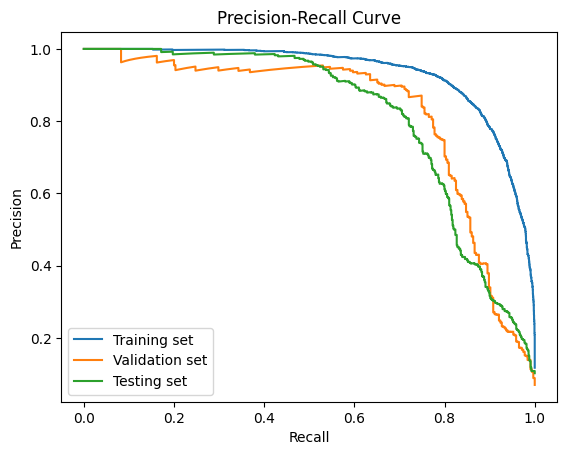

In [ ]:
y_scores = evaluate(trained_sage)

In [ ]:
evaluate_by_timesteps(trained_sage)

,time_step,pr-auc,precision(p=0.5),recall(p=0.5),f1(p=0.5),illicit rate
0,38,0.8420,0.3794,0.9640,0.5445,0.1468
1,39,0.6921,0.3480,0.8765,0.4982,0.0685
2,40,0.6771,0.3295,0.7589,0.4595,0.0925
3,41,0.8203,0.3270,0.8966,0.4793,0.1025
4,42,0.8823,0.4931,0.8954,0.6360,0.1110


In [ ]:
# Get the embedding matrix
h_sage = get_embeddings(trained_sage)
#torch.save(h_sage, "../gnn/embeddings/sage_embeddings.pt")
print("The embedding matrix has dimension", h_sage.shape)
h_sage

The embedding matrix has dimension torch.Size([203769, 64])


tensor([[0.0000, 0.0000, 0.7045,  ..., 0.0000, 0.0000, 0.4308],
        [0.0000, 0.8826, 0.7467,  ..., 0.7076, 0.0618, 0.3977],
        [0.0000, 0.0000, 0.5442,  ..., 0.0472, 0.5802, 1.3495],
        ...,
        [0.2344, 0.0000, 0.0000,  ..., 0.0000, 3.5270, 0.1133],
        [0.0000, 0.8155, 0.9535,  ..., 0.7125, 0.6646, 0.3145],
        [0.0000, 0.7024, 0.8574,  ..., 0.6523, 0.6821, 0.0000]])

In [ ]:
#torch.save(trained_sage.state_dict(), "../gnn/models/best_sage.pt")

## Performance of GraphGPS

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
set_seed(7)
gps = GraphGPS(in_channels=x.size(1), hidden_channels= 32, out_channels=2, heads=4, dropout=0.3, attn_type='performer').to(device)
training_params = {'Learning rate': 1e-4, 'Weight decay': 5e-3, # optimizer hyperparamters
          'Patience': 10, 'Min Delta': 1e-4, # early stopping hyperparameters
          'Factor': 0.8, 'Threshold': 1e-3, # scheduler hyperparameters
          'Epochs': 150} # total number of epochs
trained_gps = train(gps, training_params)


Epoch 141/150, Loss: 0.2758, val_ap: 0.8261
Best average precision on the validation set is 0.8269639824486985


The PR-AUC on the training set is: 0.8793
The PR-AUC on the validation set is: 0.8268 
The PR-AUC on the testing set is: 0.8252 


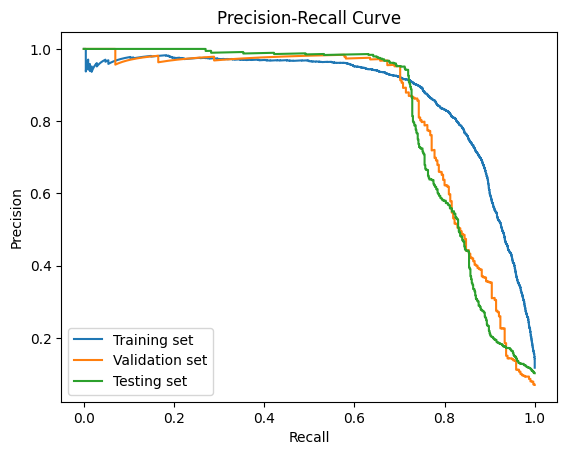

In [ ]:
y_scores = evaluate(trained_gps)

In [ ]:
evaluate_by_timesteps(trained_gps)

,time_step,pr-auc,precision(p=0.5),recall(p=0.5),f1(p=0.5),illicit rate
0,38,0.8765,0.2524,0.9369,0.3977,0.1468
1,39,0.8973,0.1733,0.9630,0.2938,0.0685
2,40,0.6728,0.1411,0.9018,0.2440,0.0925
3,41,0.8940,0.1745,0.9655,0.2955,0.1025
4,42,0.8136,0.1944,0.8954,0.3194,0.1110


In [ ]:
# Get the embedding matrix
h_gps = get_embeddings(trained_gps)
#torch.save(h_gps, "../gnn/embeddings/gps_embeddings.pt")
print("The embedding matrix has dimension", h_gps.shape)
h_gps

The embedding matrix has dimension torch.Size([203769, 32])


tensor([[ 0.0866, -0.0396,  0.0840,  ..., -0.6402, -0.2568, -0.3646],
        [-0.0859, -0.1863, -0.2586,  ...,  0.2903, -0.3102,  0.5242],
        [-0.0951, -0.1550, -0.3649,  ...,  0.0624, -0.1628,  0.2863],
        ...,
        [-0.1389, -0.1332,  0.1924,  ..., -0.7334, -0.2148, -0.3565],
        [-0.0918, -0.1772, -0.3451,  ...,  0.2610, -0.2584,  0.6239],
        [-0.0686, -0.2153, -0.3061,  ...,  0.0251, -0.2296,  0.3536]])

In [ ]:
#torch.save(trained_gps.state_dict(), "../gnn/models/best_gps.pt")